# Attitude Control (Sec 5.2)

Optimize the time-varying orientation of three solar array panels to dampen
angular velocity of a tumbling spacecraft using SRP torques alone.

In [1]:
import numpy as np
from pathlib import Path
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

import base
import designer
import estimation
import nn
import raytracing
import srp_simulation
import physics
import integrator
from utils import load_trajectory, sample_moonsun_cubic

jax.config.update('jax_enable_x64', True)

OBJECT_NAME = 'gps2f_BW_orthopanels/gps2f_3panels'
DESIGN_NAME = 'panel_rotation_sweep'
FORCE_DATA_PATH = base.get_force_path(OBJECT_NAME, DESIGN_NAME)
PLOT_DIR = base.PROJECT_ROOT / 'plots' / '3panels_rotation_experiments'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

/Users/charlesc/anaconda3/envs/photonsxforce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROT_ANGLE_DEG = 180.0
max_tilt = jnp.deg2rad(ROT_ANGLE_DEG)

rotation_specs = [
    designer.make_panel_rotation_spec('S_Arr_1_Array_mat', pivot_axis='y', max_tilt_rad=max_tilt),
    designer.make_panel_rotation_spec('S_Arr_2_Array_mat', pivot_axis='x', max_tilt_rad=max_tilt),
    designer.make_panel_rotation_spec('S_Arr_3_Array_mat', pivot_axis='z', max_tilt_rad=max_tilt),
]
rotation_design = designer.build_panel_rotation_design(OBJECT_NAME, rotation_specs, max_tilt_rad=max_tilt)
designer.my_design = rotation_design
print(f'Design dimensions: {rotation_design.shape}')

Design dimensions: 3


In [3]:
SUN_GRID = (90, 180)
MC_SAMPLES = 10_000
LOAD_PRECOMPUTED = True

force_prefix = str(Path(FORCE_DATA_PATH))

if LOAD_PRECOMPUTED:
    force_flat = np.load(force_prefix + '_force.npy')
    torque_flat = np.load(force_prefix + '_torque.npy')
    dir_flat = np.load(force_prefix + '_directions.npy')
    raw_param_flat = np.load(force_prefix + '_parameters.npy')
    print('Loaded precomputed force/torque maps')
else:
    mesh = raytracing.load_mesh(base.get_mesh_name(OBJECT_NAME))
    force, torque, sun_dirs, params = srp_simulation.build_force_map(
        SUN_GRID, MC_SAMPLES, estimation.estimate_backward, mesh, rotation_design,
        profile_interval=max(1, MC_SAMPLES // 10))
    force_flat = np.array(force).reshape(-1, 3)
    torque_flat = np.array(torque).reshape(-1, 3)
    dir_flat = np.array(sun_dirs).reshape(-1, 3)
    raw_param_flat = np.array(params).reshape(-1, rotation_design.shape)
    for suffix, arr in [('_force', force_flat), ('_torque', torque_flat),
                        ('_directions', dir_flat), ('_parameters', raw_param_flat)]:
        np.save(force_prefix + suffix + '.npy', arr)
    print('Saved force/torque maps')

Loaded precomputed force/torque maps


In [4]:
LOAD_PRETRAINED = True

nn.train_combined_proxy(
    OBJECT_NAME, DESIGN_NAME, SUN_GRID,
    feature_suffix='_parameters.npy', direction_suffix='_directions.npy',
    force_suffix='_force.npy', torque_suffix='_torque.npy',
    weight_prefix='combined', checkpoint_name='combined_training_checkpoint.pkl',
    load_pretrained=LOAD_PRETRAINED,
    num_hidden_layers=5, hidden_width=192, max_steps=3_000,
    log_every=1000, diag_every=999)

print('NN weights:', base.get_nn_weight_path(OBJECT_NAME, DESIGN_NAME))

NN weights: /Users/charlesc/Documents/GitHub/photonsXforce/data/nn_weights/gps2f_BW_orthopanels/gps2f_3panels_panel_rotation_sweep/


In [5]:
SIM_HOURS = 6
STEP_SIZE = 30.0
STEP_COUNT = int(SIM_HOURS * 3600 / STEP_SIZE)
CONTROL_INTERVAL = 5 * 60
CONTROL_COUNT = int(SIM_HOURS * 3600 / CONTROL_INTERVAL) + 1

SC_MASS = 500.0
MOI = jnp.array([0.1, 0.1, 0.1], dtype=jnp.float64)
TORQUE_GAIN = 2

trajectory = load_trajectory(base.drive_path + 'trajectories/gps08.csv', limit=None)
t0 = float(trajectory.time[0])
t1 = t0 + SIM_HOURS * 3600
sun_positions = jnp.asarray(trajectory.sun, dtype=jnp.float64)
sun_times = jnp.asarray(trajectory.time, dtype=jnp.float64)
control_times = jnp.asarray(t0 + CONTROL_INTERVAL * jnp.arange(CONTROL_COUNT), dtype=jnp.float64)

print(f'{SIM_HOURS}h, {STEP_COUNT} steps, {CONTROL_COUNT} control points')

6h, 720 steps, 73 control points


In [6]:
def qmul(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return jnp.array([
        w1*w2-x1*x2-y1*y2-z1*z2, w1*x2+x1*w2+y1*z2-z1*y2,
        w1*y2-x1*z2+y1*w2+z1*x2, w1*z2+x1*y2-y1*x2+z1*w2])

def qnorm(q): return q / jnp.linalg.norm(q)

def quat_to_rotmat(q):
    w, x, y, z = qnorm(q)
    return jnp.array([
        [1-2*(y*y+z*z), 2*(x*y-w*z), 2*(x*z+w*y)],
        [2*(x*y+w*z), 1-2*(x*x+z*z), 2*(y*z-w*x)],
        [2*(x*z-w*y), 2*(y*z+w*x), 1-2*(x*x+y*y)]])

def qdot(q, omega):
    return 0.5 * qmul(q, jnp.array([0., omega[0], omega[1], omega[2]]))

def rotmat_to_quat(R):
    w = jnp.sqrt(jnp.maximum(0, 1+jnp.trace(R))) / 2
    x = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1+R[0,0]-R[1,1]-R[2,2]))/2, R[2,1]-R[1,2])
    y = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1-R[0,0]+R[1,1]-R[2,2]))/2, R[0,2]-R[2,0])
    z = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1-R[0,0]-R[1,1]+R[2,2]))/2, R[1,0]-R[0,1])
    return jnp.array([w, x, y, z])

In [7]:
pos0 = jnp.asarray(trajectory.position[0], dtype=jnp.float64)
vel0 = jnp.asarray(trajectory.velocity[0], dtype=jnp.float64)
sun0 = jnp.asarray(trajectory.sun[0], dtype=jnp.float64)

z_sc = -pos0 / jnp.linalg.norm(pos0)
y_sc = jnp.cross(sun0 / jnp.linalg.norm(sun0), -z_sc)
y_sc = y_sc / jnp.linalg.norm(y_sc)
x_sc = jnp.cross(y_sc, z_sc)
x_sc = x_sc / jnp.linalg.norm(x_sc)

q0 = qnorm(rotmat_to_quat(jnp.column_stack([x_sc, y_sc, z_sc])))
omega0 = jnp.deg2rad(jnp.array([0.05, 0.05, 0.02]))
state0 = (pos0, vel0, q0, omega0)

In [8]:
panel_count = int(rotation_design.shape)
panel_limits = jnp.full((panel_count,), jnp.deg2rad(ROT_ANGLE_DEG), dtype=jnp.float64)

nn_dir = Path(base.get_nn_weight_path(OBJECT_NAME, DESIGN_NAME))
bundles = {}
for kind in ['force', 'torque']:
    p = nn.load_nn_parameters(nn_dir / f'{kind}_parameters.bin')
    f = nn.load_nn_parameters(nn_dir / f'{kind}_ray_stats.bin')
    t = nn.load_nn_parameters(nn_dir / f'{kind}_target_stats.bin')
    bundles[kind] = {
        'params': tuple(jnp.asarray(v, dtype=jnp.float64) for v in p),
        'feat': tuple(jnp.asarray(v, dtype=jnp.float64) for v in f),
        'tgt': tuple(jnp.asarray(v, dtype=jnp.float64) for v in t),
    }

def eval_nn(bundle, features):
    w = nn.whiten_with_stats(features, bundle['feat'])
    return nn.unwhiten(0.5 * (nn.mlp(w, bundle['params']) + 1.0), bundle['tgt'])

def query_proxy(sun_body, angles):
    feat = jnp.concatenate([sun_body, 0.5 * (angles / panel_limits + 1.0)])
    return eval_nn(bundles['force'], feat), eval_nn(bundles['torque'], feat) * TORQUE_GAIN

print(f'Loaded force+torque NN ({panel_count} panels)')

Loaded force+torque NN (3 panels)


In [9]:
def softsign(x): return x / (1.0 + jnp.abs(x))
def params_to_angles(raw): return jnp.clip(panel_limits * softsign(raw), -panel_limits, panel_limits)

def build_provider(angle_table):
    def provider(position, time, quat):
        idx = jnp.clip(jnp.searchsorted(control_times, time, side='right'), 1, angle_table.shape[0]-1)
        alpha = jnp.clip((time - control_times[idx-1]) / jnp.maximum(control_times[idx] - control_times[idx-1], 1e-9), 0., 1.)
        angles = (1-alpha) * angle_table[idx-1] + alpha * angle_table[idx]
        sun_pos = sample_moonsun_cubic(time, sun_positions, sun_times)
        R = quat_to_rotmat(quat)
        sun_body = R.T @ ((sun_pos - position) / jnp.maximum(jnp.linalg.norm(sun_pos - position), 1e-12))
        force_body, torque_body = query_proxy(sun_body, angles)
        return R @ force_body / SC_MASS, torque_body
    return provider

def dynamics(state, time, provider, moi):
    pos, vel, quat, omega = state
    gravity = -physics.GM * pos / jnp.linalg.norm(pos)**3
    srp_acc, torque = provider(pos, time, quat)
    return (vel, gravity + srp_acc, qdot(quat, omega),
            (torque - jnp.cross(omega, moi * omega)) / moi)

def simulate(control_table):
    provider = build_provider(params_to_angles(control_table))
    dt = (t1 - t0) / STEP_COUNT
    def step(carry, t):
        new = integrator.integrate_rk4(carry, t, dynamics, provider, dt, MOI)
        return (new[0], new[1], qnorm(new[2]), new[3]), carry
    final, hist = jax.lax.scan(step, state0, t0 + dt * jnp.arange(STEP_COUNT))
    hist = jax.tree.map(lambda h, f: jnp.concatenate([h, f[None]], axis=0), hist, final)
    return jnp.concatenate([t0 + dt * jnp.arange(STEP_COUNT), jnp.array([t1])]), hist

In [10]:
N_ITERS = 100

def loss_fn(raw):
    _, states = simulate(params_to_angles(raw))
    omega_mag = jnp.linalg.norm(states[3], axis=-1)
    return jnp.sqrt(jnp.mean((omega_mag / (omega_mag[0] + 1e-6))**2))

loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))

params = jnp.zeros((CONTROL_COUNT, panel_count), dtype=jnp.float64)
optimizer = optax.adam(5e-3)
opt_state = optimizer.init(params)
losses, best_params, best_loss = [], None, float('inf')

for i in range(N_ITERS):
    l, g = loss_and_grad(params)
    losses.append(float(l))
    if float(l) < best_loss:
        best_loss, best_params = float(l), params
    updates, opt_state = optimizer.update(g, opt_state, params)
    params = optax.apply_updates(params, updates)
    if i % max(1, N_ITERS // 10) == 0:
        print(f'iter {i:5d}  loss={l:.6f}')

print(f'Best loss: {best_loss:.6f}')

iter     0  loss=2.473973


iter    10  loss=2.638810


iter    20  loss=2.121865


iter    30  loss=2.027828


iter    40  loss=1.957990


...

iter    60  loss=1.896173


iter    70  loss=1.879922


iter    80  loss=1.876645


iter    90  loss=1.875599


Best loss: 1.856833


In [11]:
opt_angles = params_to_angles(best_params)
ts_opt, states_opt = simulate(params_to_angles(best_params))
ts_base, states_base = simulate(params_to_angles(jnp.zeros((CONTROL_COUNT, panel_count))))

mins_opt = np.asarray((ts_opt - ts_opt[0]) / 60)
mins_base = np.asarray((ts_base - ts_base[0]) / 60)
omega_opt_deg = np.rad2deg(np.asarray(states_opt[3]))
omega_base_deg = np.rad2deg(np.asarray(states_base[3]))

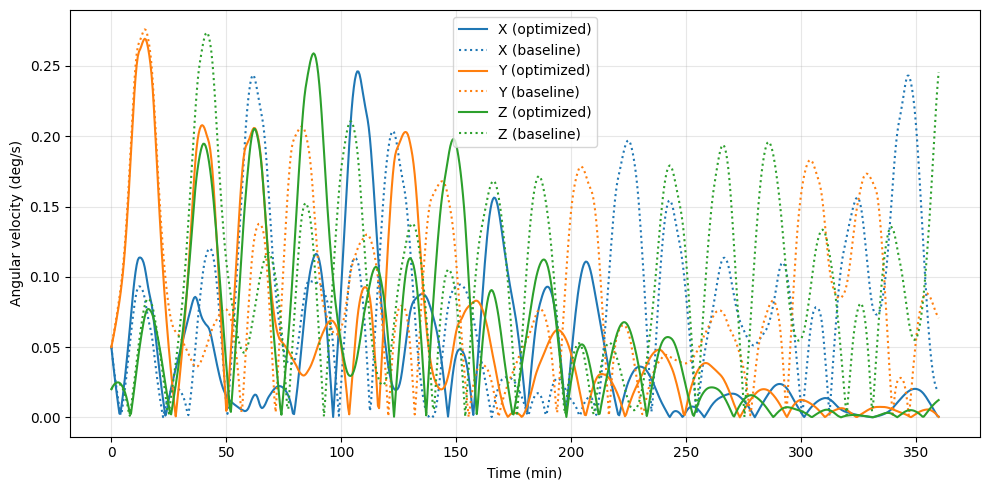

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for j, label in enumerate(['X', 'Y', 'Z']):
    ax.plot(mins_opt, np.abs(omega_opt_deg[:, j]), f'C{j}-', label=f'{label} (optimized)')
    ax.plot(mins_base, np.abs(omega_base_deg[:, j]), f'C{j}:', label=f'{label} (baseline)')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Angular velocity (deg/s)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'spin_profile_quat_downsampled.svg'))
plt.show()

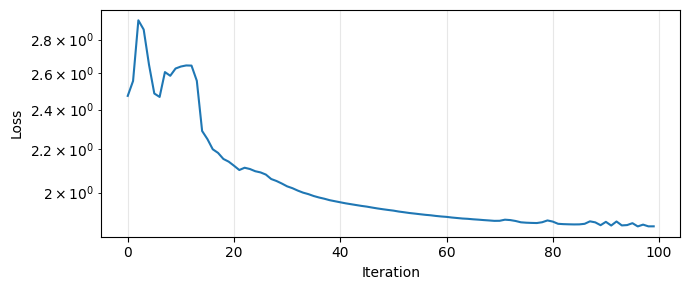

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses)
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'loss_trace_quat_downsampled.svg'))
plt.show()

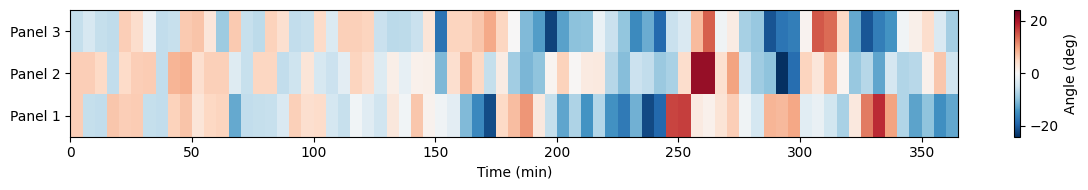

In [14]:
ctrl_min = np.arange(CONTROL_COUNT) * CONTROL_INTERVAL / 60
opt_cmd_deg = np.rad2deg(np.asarray(opt_angles))

fig, ax = plt.subplots(figsize=(12, 2))
dt_min = ctrl_min[1] - ctrl_min[0] if len(ctrl_min) > 1 else 5.0
t_edges = np.concatenate([ctrl_min, [ctrl_min[-1] + dt_min]])
vmax = np.max(np.abs(opt_cmd_deg))
im = ax.pcolormesh(t_edges, np.arange(panel_count + 1), opt_cmd_deg.T,
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='flat')
ax.set_xlabel('Time (min)')
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(['Panel 1', 'Panel 2', 'Panel 3'])
plt.colorbar(im, ax=ax, label='Angle (deg)')
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'final_panel_commands_heatmap.svg'))
plt.show()